In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df

,age,sex,bmi,children,smoker,region,charges
0,58,male,15.75,0,no,southwest,19931.80
1,52,male,32.71,0,yes,southeast,44961.99
2,30,female,21.61,2,no,southwest,15818.23
3,28,female,25.21,0,no,northwest,12971.84
4,42,male,25.77,1,no,southwest,19549.93
...,...,...,...,...,...,...,...
995,50,male,39.20,1,yes,southeast,44521.89
996,34,female,38.55,3,no,northwest,22850.27
997,62,male,36.19,4,no,northeast,29807.59
998,25,male,38.45,2,no,southwest,19879.44


##EDA

In [4]:
df.shape

(1000, 7)

In [5]:
df.head

<bound method NDFrame.head of      age     sex    bmi  children smoker     region   charges
0     58    male  15.75         0     no  southwest  19931.80
1     52    male  32.71         0    yes  southeast  44961.99
2     30  female  21.61         2     no  southwest  15818.23
3     28  female  25.21         0     no  northwest  12971.84
4     42    male  25.77         1     no  southwest  19549.93
..   ...     ...    ...       ...    ...        ...       ...
995   50    male  39.20         1    yes  southeast  44521.89
996   34  female  38.55         3     no  northwest  22850.27
997   62    male  36.19         4     no  northeast  29807.59
998   25    male  38.45         2     no  southwest  19879.44
999   20    male  20.01         0     no  northwest   9631.13

[1000 rows x 7 columns]>

In [6]:
df.describe() ## only numeric data will come 

,age,bmi,children,charges
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,42.144000,30.274820,1.515000,24909.348910
std,13.781553,8.512654,1.364418,10669.276286
min,18.000000,15.010000,0.000000,8227.800000
25%,30.000000,22.947500,0.000000,17603.155000
50%,43.000000,29.910000,1.000000,21878.460000
75%,54.000000,37.812500,2.000000,26910.970000
max,64.000000,44.980000,5.000000,57666.690000


In [7]:
df.isnull().sum() ## check the null value 

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

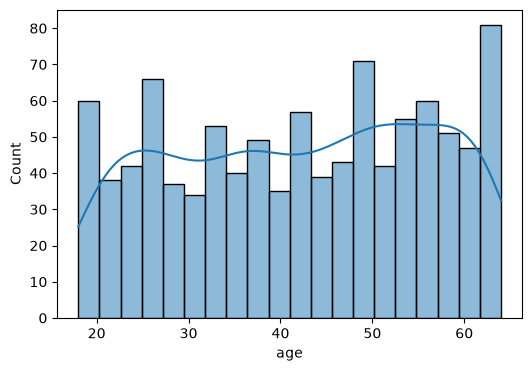

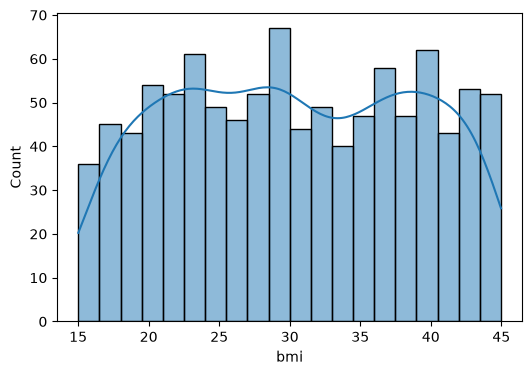

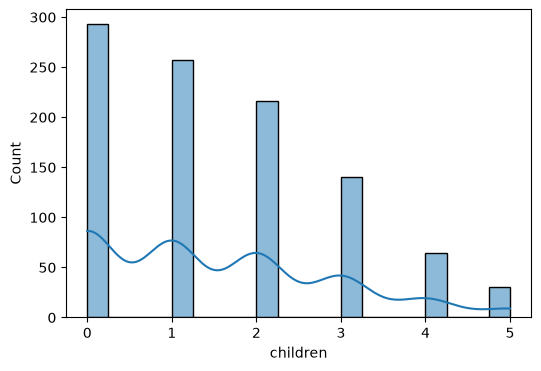

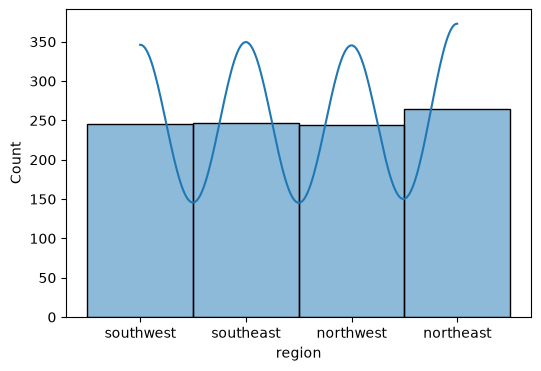

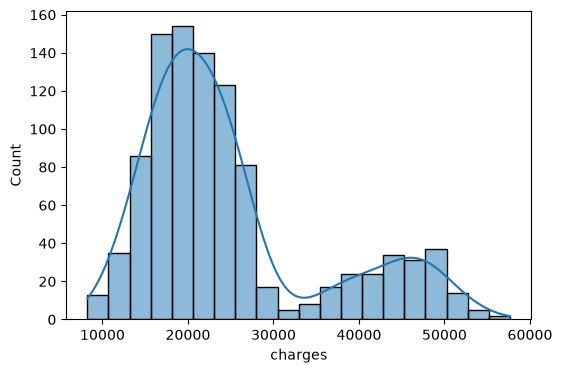

In [9]:
numeric_columns = ['age','bmi', 'children','region', 'charges']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde = True,bins = 20)
    

<Axes: xlabel='children', ylabel='count'>

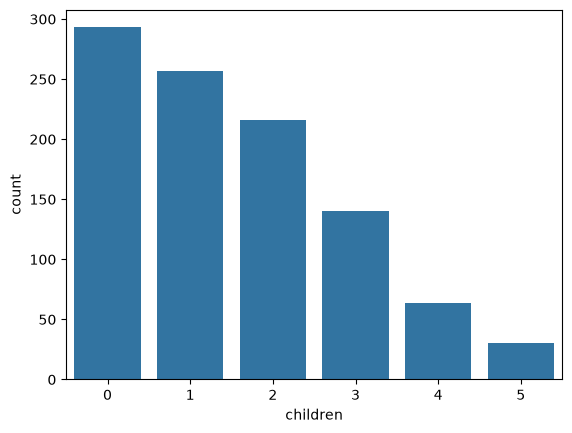

In [10]:
sns.countplot(x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

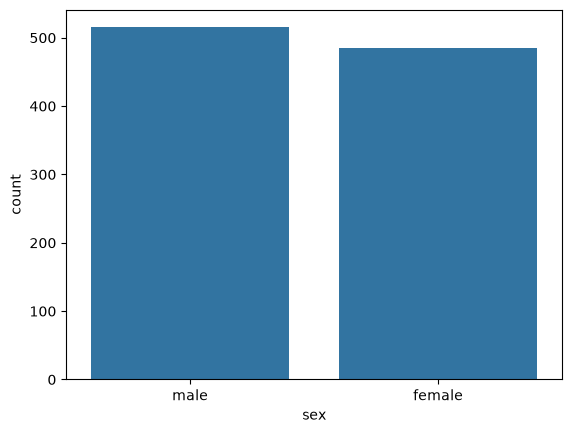

In [11]:
sns.countplot(x= df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

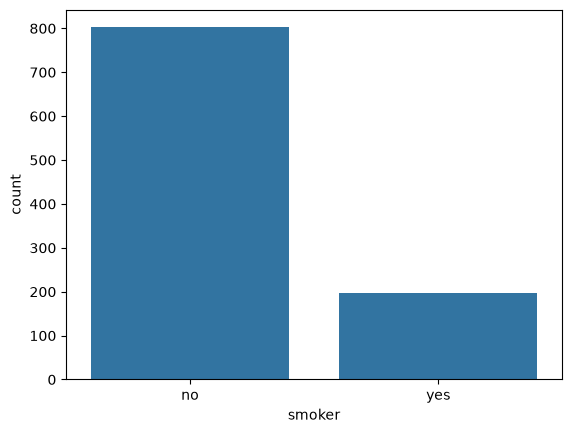

In [12]:
sns.countplot(x= df['smoker'])

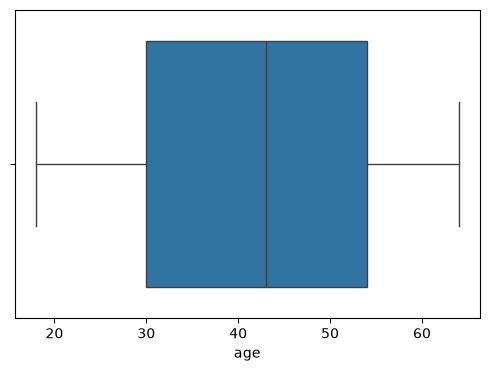

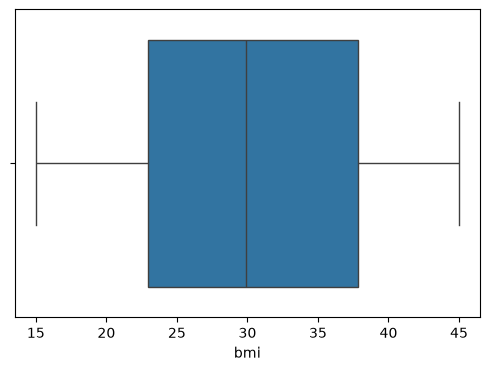

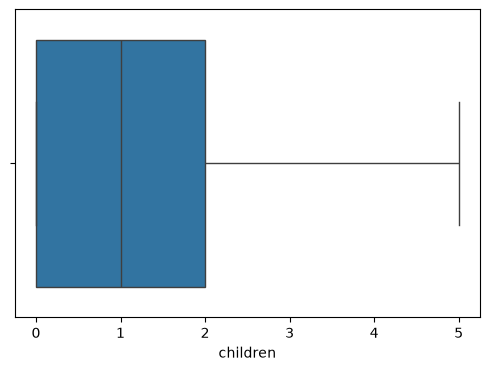

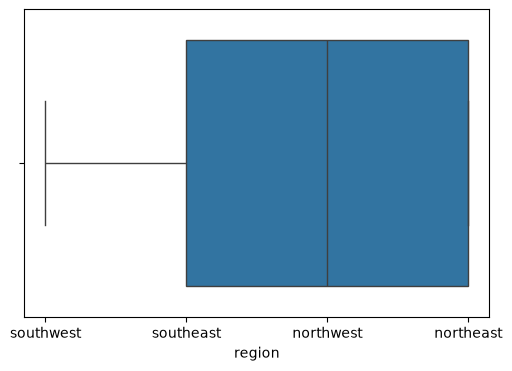

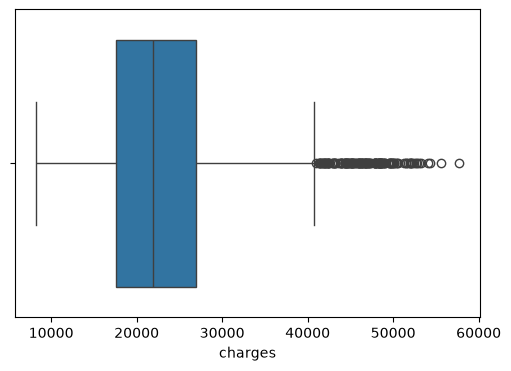

In [13]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x = df[col])

<Axes: >

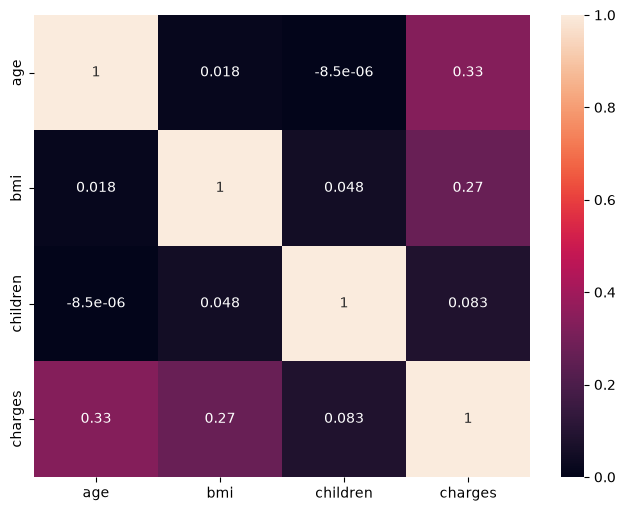

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

## Data Cleaning and Preprocessig

In [15]:
df_cleaned= df.copy()

In [16]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,58,male,15.75,0,no,southwest,19931.80
1,52,male,32.71,0,yes,southeast,44961.99
2,30,female,21.61,2,no,southwest,15818.23
3,28,female,25.21,0,no,northwest,12971.84
4,42,male,25.77,1,no,southwest,19549.93


In [17]:
df_cleaned.shape

(1000, 7)

In [18]:
df_cleaned.drop_duplicates(inplace=True)

In [19]:
df_cleaned.shape

(1000, 7)

In [20]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [21]:
df_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [22]:
df_cleaned.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [23]:
df_cleaned['sex'].value_counts()

sex
male      515
female    485
Name: count, dtype: int64

In [24]:
df_cleaned['sex'] = df_cleaned['sex'].map({"male" : 0,"female" : 1})  ## ancode kar diye 0,1 me 

In [25]:
df_cleaned.head

<bound method NDFrame.head of      age  sex    bmi  children smoker     region   charges
0     58    0  15.75         0     no  southwest  19931.80
1     52    0  32.71         0    yes  southeast  44961.99
2     30    1  21.61         2     no  southwest  15818.23
3     28    1  25.21         0     no  northwest  12971.84
4     42    0  25.77         1     no  southwest  19549.93
..   ...  ...    ...       ...    ...        ...       ...
995   50    0  39.20         1    yes  southeast  44521.89
996   34    1  38.55         3     no  northwest  22850.27
997   62    0  36.19         4     no  northeast  29807.59
998   25    0  38.45         2     no  southwest  19879.44
999   20    0  20.01         0     no  northwest   9631.13

[1000 rows x 7 columns]>

In [26]:
df_cleaned['smoker'].value_counts()

smoker
no     802
yes    198
Name: count, dtype: int64

In [27]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({"no" : 0,"yes" : 1})

In [28]:
df_cleaned.head

<bound method NDFrame.head of      age  sex    bmi  children  smoker     region   charges
0     58    0  15.75         0       0  southwest  19931.80
1     52    0  32.71         0       1  southeast  44961.99
2     30    1  21.61         2       0  southwest  15818.23
3     28    1  25.21         0       0  northwest  12971.84
4     42    0  25.77         1       0  southwest  19549.93
..   ...  ...    ...       ...     ...        ...       ...
995   50    0  39.20         1       1  southeast  44521.89
996   34    1  38.55         3       0  northwest  22850.27
997   62    0  36.19         4       0  northeast  29807.59
998   25    0  38.45         2       0  southwest  19879.44
999   20    0  20.01         0       0  northwest   9631.13

[1000 rows x 7 columns]>

In [29]:
df_cleaned.rename(columns={
    'sex':'is_female',
    'smoker': 'is _smoker'
},inplace = True)

In [30]:
df_cleaned.head

<bound method NDFrame.head of      age  is_female    bmi  children  is _smoker     region   charges
0     58          0  15.75         0           0  southwest  19931.80
1     52          0  32.71         0           1  southeast  44961.99
2     30          1  21.61         2           0  southwest  15818.23
3     28          1  25.21         0           0  northwest  12971.84
4     42          0  25.77         1           0  southwest  19549.93
..   ...        ...    ...       ...         ...        ...       ...
995   50          0  39.20         1           1  southeast  44521.89
996   34          1  38.55         3           0  northwest  22850.27
997   62          0  36.19         4           0  northeast  29807.59
998   25          0  38.45         2           0  southwest  19879.44
999   20          0  20.01         0           0  northwest   9631.13

[1000 rows x 7 columns]>

In [31]:
df['region'].value_counts()

region
northeast    264
southeast    247
southwest    245
northwest    244
Name: count, dtype: int64

In [32]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['region'],drop_first=True)

In [33]:
df_cleaned.head()

,age,is_female,bmi,children,is _smoker,charges,region_northwest,region_southeast,region_southwest
0,58,0,15.75,0,0,19931.80,False,False,True
1,52,0,32.71,0,1,44961.99,False,True,False
2,30,1,21.61,2,0,15818.23,False,False,True
3,28,1,25.21,0,0,12971.84,True,False,False
4,42,0,25.77,1,0,19549.93,False,False,True


In [34]:
df_cleaned = df_cleaned.astype(int)

In [35]:
df_cleaned

,age,is_female,bmi,children,is _smoker,charges,region_northwest,region_southeast,region_southwest
0,58,0,15,0,0,19931,0,0,1
1,52,0,32,0,1,44961,0,1,0
2,30,1,21,2,0,15818,0,0,1
3,28,1,25,0,0,12971,1,0,0
4,42,0,25,1,0,19549,0,0,1
...,...,...,...,...,...,...,...,...,...
995,50,0,39,1,1,44521,0,1,0
996,34,1,38,3,0,22850,1,0,0
997,62,0,36,4,0,29807,0,0,0
998,25,0,38,2,0,19879,0,0,1


## Features  Engineering and Extraction

<Axes: ylabel='Count'>

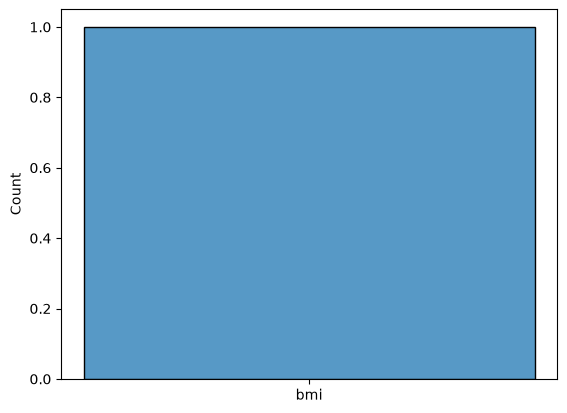

In [36]:
sns.histplot(['bmi'])

In [37]:
df_cleaned['bmi_category'] = pd.cut(
    df_cleaned['bmi'],
    bins=[0,18.4,24.5,29.5,float('inf')],
    labels=['Underweight','Normal','Overweight','obese']
)

In [38]:
df_cleaned

,age,is_female,bmi,children,is _smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,58,0,15,0,0,19931,0,0,1,Underweight
1,52,0,32,0,1,44961,0,1,0,obese
2,30,1,21,2,0,15818,0,0,1,Normal
3,28,1,25,0,0,12971,1,0,0,Overweight
4,42,0,25,1,0,19549,0,0,1,Overweight
...,...,...,...,...,...,...,...,...,...,...
995,50,0,39,1,1,44521,0,1,0,obese
996,34,1,38,3,0,22850,1,0,0,obese
997,62,0,36,4,0,29807,0,0,0,obese
998,25,0,38,2,0,19879,0,0,1,obese


In [39]:
df_cleaned = pd.get_dummies(df_cleaned,columns = ['bmi_category'],drop_first=True)

In [40]:
df_cleaned

,age,is_female,bmi,children,is _smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_obese
0,58,0,15,0,0,19931,0,0,1,False,False,False
1,52,0,32,0,1,44961,0,1,0,False,False,True
2,30,1,21,2,0,15818,0,0,1,True,False,False
3,28,1,25,0,0,12971,1,0,0,False,True,False
4,42,0,25,1,0,19549,0,0,1,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
995,50,0,39,1,1,44521,0,1,0,False,False,True
996,34,1,38,3,0,22850,1,0,0,False,False,True
997,62,0,36,4,0,29807,0,0,0,False,False,True
998,25,0,38,2,0,19879,0,0,1,False,False,True


In [41]:
df_cleaned = df_cleaned.astype(int)

In [42]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is _smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_obese'],
      dtype='str')

In [44]:
from sklearn.preprocessing import StandardScaler

cols = ['age', 'bmi', 'children']

scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [45]:
df_cleaned.head()


,age,is_female,bmi,children,is _smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_obese
0,1.151099,0,-1.737146,-1.110919,0,19931,0,0,1,0,0,0
1,0.715517,0,0.260925,-1.110919,1,44961,0,1,0,0,0,1
2,-0.881619,1,-1.031945,0.355641,0,15818,0,0,1,1,0,0
3,-1.026813,1,-0.561810,-1.110919,0,12971,1,0,0,0,1,0
4,-0.010454,0,-0.561810,-0.377639,0,19549,0,0,1,0,1,0


NameError: name 'df_cleaned' is not defined

In [5]:
df_cleaned = df.dropna()


NameError: name 'df' is not defined

In [ ]:
### pearson corelation 